<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/Handwritten_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sachinpatel21/az-handwritten-alphabets-in-csv-format")

print("Path to dataset files:", path)

100%|██████████| 185M/185M [00:00<00:00, 226MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/versions/5


# **Loading Data Set**

In [6]:
import pandas as pd
import os
import numpy as np

In [7]:
csv_path = os.path.join(path, "A_Z Handwritten Data.csv")

In [8]:
df = pd.read_csv(csv_path)

In [9]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **Data Analysis**

In [10]:
df.shape

(372450, 785)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: int64(785)
memory usage: 2.2 GB


In [13]:
df.isnull().sum()

,0
0,0
0.1,0
0.2,0
0.3,0
0.4,0
...,...
0.644,0
0.645,0
0.646,0
0.647,0


In [14]:
df.tail()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
372445,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372446,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372447,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372448,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372449,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df['0'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25])

In [16]:
df.rename(columns={'0':'output'}, inplace=True)

In [17]:
word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}


In [18]:
df['output'].value_counts()

,count
output,
14,57825
18,48419
20,29008
2,23409
19,22495
15,19341
13,19010
0,13869
12,12336


In [19]:
X = df.drop(columns=['output'])
y = df['output']

In [20]:
y = y.astype(int)

# **Data Visualization**

In [21]:
from matplotlib import pyplot as plt
import seaborn as sns

In [22]:
alphabet_counts = y.value_counts().sort_index()
alphabet_counts.index = alphabet_counts.index.map(word_dict)

/tmp/ipython-input-2387498537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alphabet_counts.index, y=alphabet_counts.values, palette='viridis')


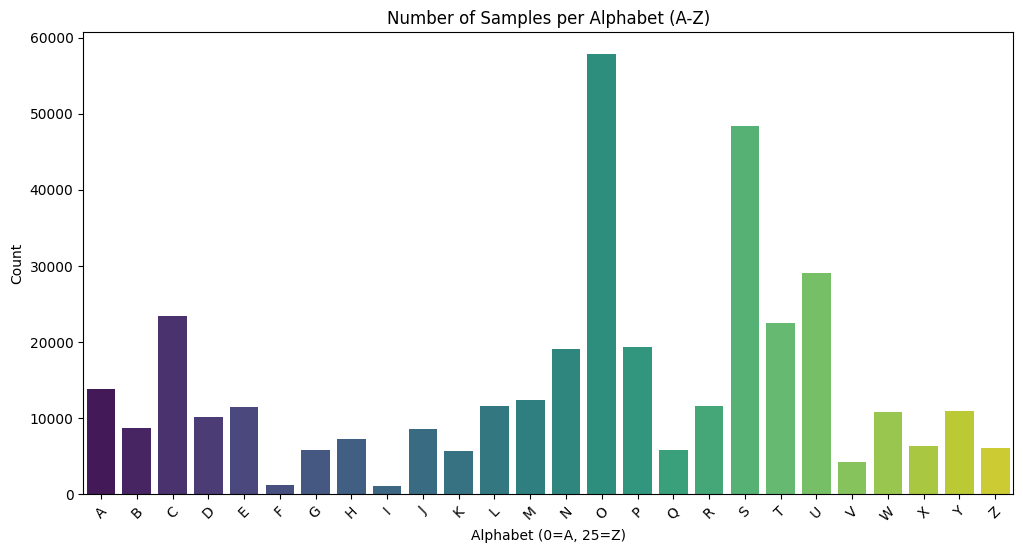

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(x=alphabet_counts.index, y=alphabet_counts.values, palette='viridis')
plt.title("Number of Samples per Alphabet (A-Z)")
plt.xlabel("Alphabet (0=A, 25=Z)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

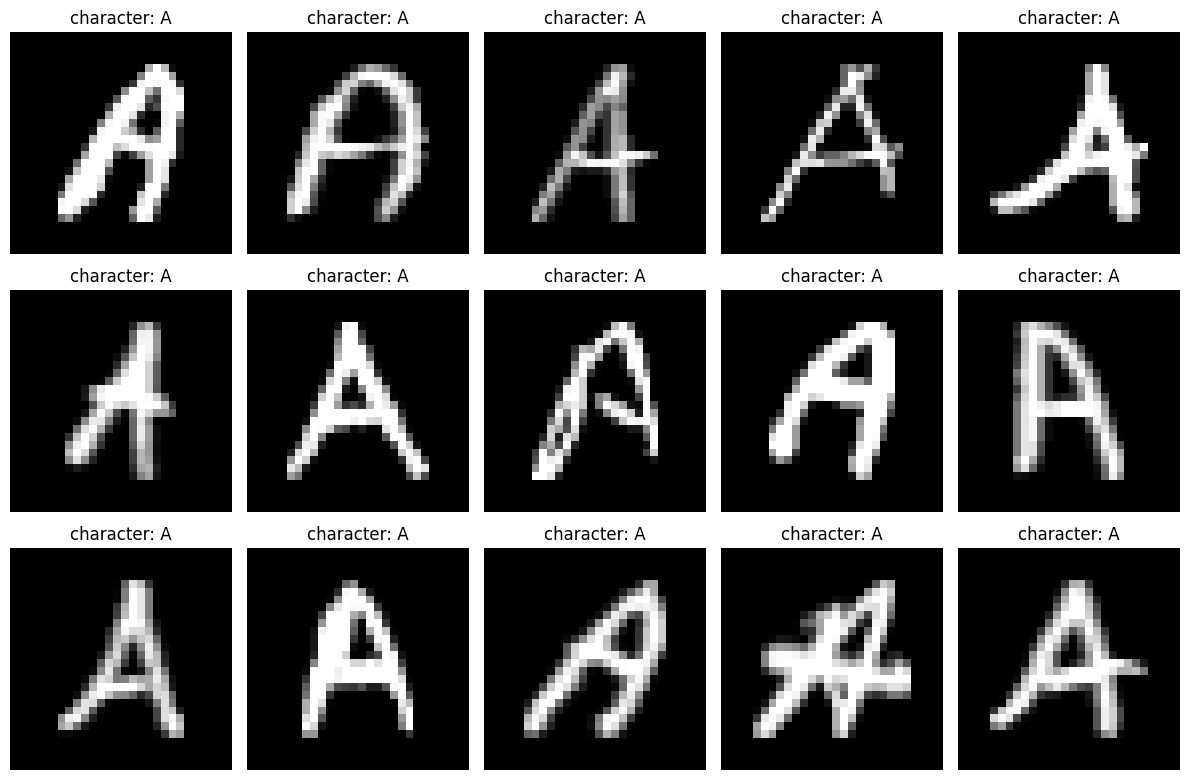

In [24]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img = X.iloc[i].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"character: {chr(65 + int(y[i]))}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# **Machine Learning Model Training**

In [25]:
from sklearn.model_selection import train_test_split

**Preprocessing Data**

In [26]:
X = X / 255.0

**Splitting Data**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (297960, 784)
Test data shape: (74490, 784)


# **Model Building**

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [29]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **Evaluating Model**

In [30]:
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")

Random Forest Results:
Accuracy: 0.9876


# **Classification Report**

In [31]:
print(classification_report(y_test, rf_pred, target_names=list(word_dict.values())))

              precision    recall  f1-score   support

           A       0.97      0.99      0.98      2806
           B       0.98      0.98      0.98      1673
           C       0.99      0.99      0.99      4742
           D       0.98      0.96      0.97      2044
           E       0.99      0.98      0.99      2214
           F       1.00      0.94      0.97       231
           G       0.99      0.97      0.98      1183
           H       0.98      0.96      0.97      1466
           I       1.00      0.96      0.98       237
           J       0.98      0.97      0.98      1668
           K       0.98      0.96      0.97      1132
           L       1.00      1.00      1.00      2319
           M       0.98      0.97      0.98      2487
           N       0.98      0.99      0.98      3756
           O       0.99      1.00      0.99     11629
           P       0.99      0.99      0.99      3868
           Q       0.99      0.95      0.97      1159
           R       0.98    

# **Visualizing Prediction**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

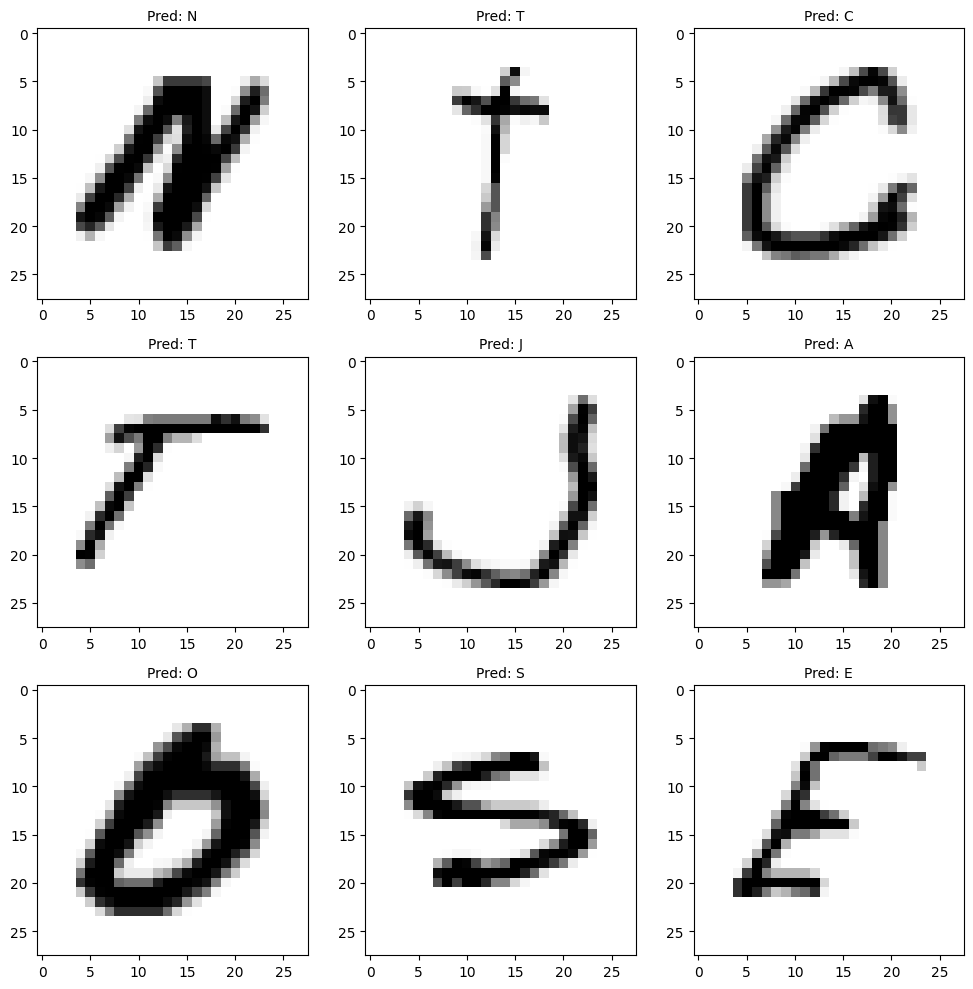

In [32]:
sample_indices = np.random.choice(len(X_test), 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = X_test.iloc[sample_indices[i]].values.reshape(28, 28)
    true_label = word_dict[y_test.iloc[sample_indices[i]]]

    rf_pred = word_dict[rf_model.predict([X_test.iloc[sample_indices[i]]])[0]]

    ax.imshow(img, cmap='Greys')
    ax.set_title(f"Pred: {rf_pred}", fontsize=10)

plt.tight_layout()
plt.show()

# **Now Using CNN**

In [35]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.utils import to_categorical

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [36]:
X = X.values.reshape(-1, 28, 28, 1)
y = to_categorical(y, num_classes=26)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test))

Epoch 1/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 89s 19ms/step - accuracy: 0.8463 - loss: 0.5350 - val_accuracy: 0.9808 - val_loss: 0.0698
Epoch 2/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 91s 20ms/step - accuracy: 0.9653 - loss: 0.1240 - val_accuracy: 0.9863 - val_loss: 0.0522
Epoch 3/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 89s 19ms/step - accuracy: 0.9754 - loss: 0.0891 - val_accuracy: 0.9879 - val_loss: 0.0443
Epoch 4/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.9794 - loss: 0.0726 - val_accuracy: 0.9893 - val_loss: 0.0411
Epoch 5/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.9816 - loss: 0.0645 - val_accuracy: 0.9886 - val_loss: 0.0423
Epoch 6/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 86s 18ms/step - accuracy: 0.9837 - loss: 0.0568 - val_accuracy: 0.9904 - val_loss: 0.0389
Epoch 7/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 88s 19ms/step - accuracy: 0.9848 - loss: 0.0514 - val_accuracy: 0.9918 - val_loss: 0.0332
Epoch 8/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 87s 19ms/step - accuracy: 0.9863 -

# **Visualizing CNN Performance**

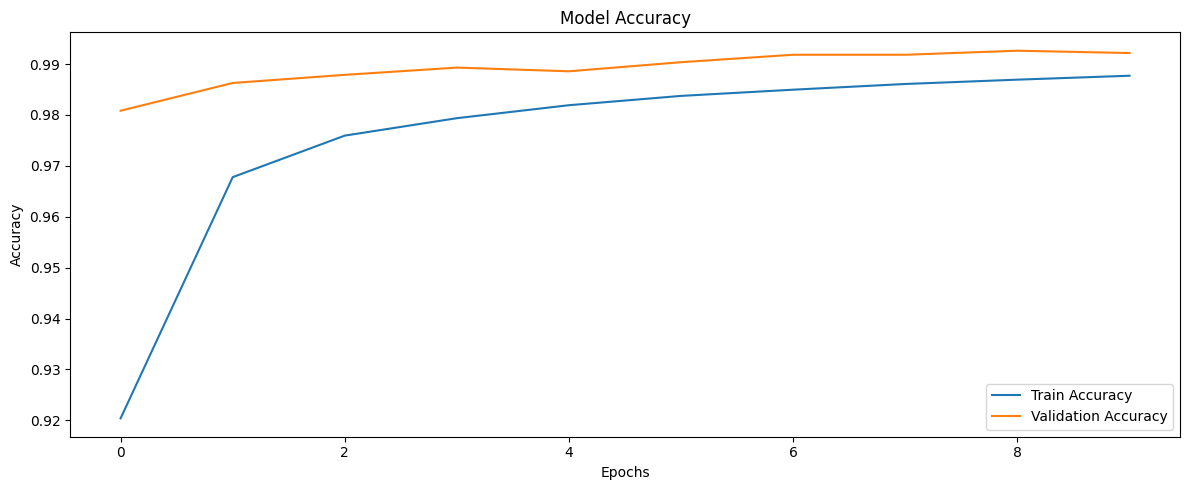

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

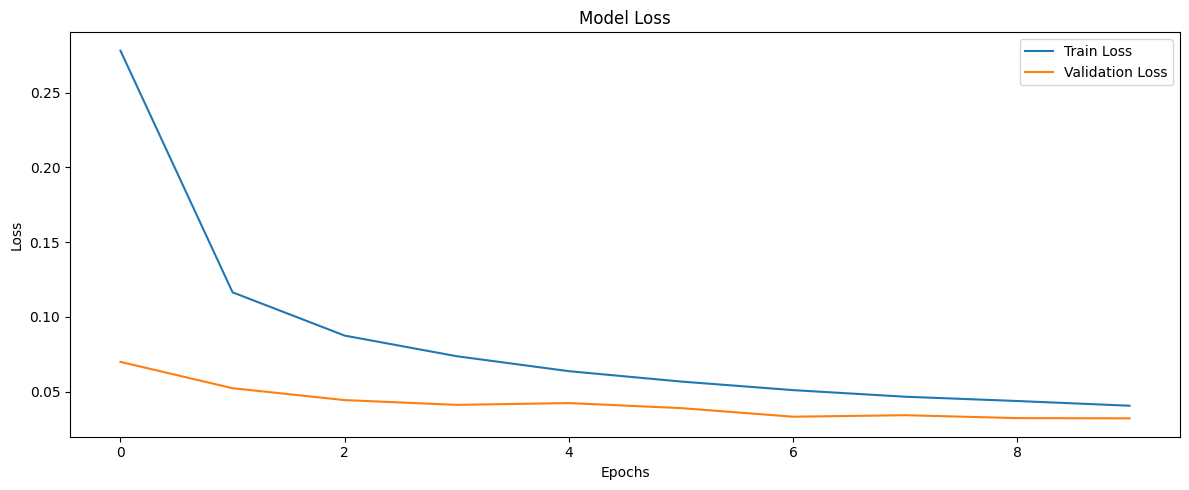

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **Now using RNN**

In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

In [45]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Labels to one-hot
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [46]:
model = Sequential()

In [47]:
model.add(LSTM(128, input_shape=(28, 28), return_sequences=False))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.add(Dropout(0.2))

In [49]:
model.add(Dense(64, activation='relu'))

In [50]:
model.add(Dense(10, activation='softmax'))

In [51]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [52]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/10
375/375 - 13s - 34ms/step - accuracy: 0.7737 - loss: 0.6778 - val_accuracy: 0.9274 - val_loss: 0.2346
Epoch 2/10
375/375 - 12s - 31ms/step - accuracy: 0.9389 - loss: 0.2026 - val_accuracy: 0.9574 - val_loss: 0.1404
Epoch 3/10
375/375 - 12s - 32ms/step - accuracy: 0.9584 - loss: 0.1348 - val_accuracy: 0.9636 - val_loss: 0.1158
Epoch 4/10
375/375 - 12s - 31ms/step - accuracy: 0.9676 - loss: 0.1049 - val_accuracy: 0.9705 - val_loss: 0.0936
Epoch 5/10
375/375 - 12s - 31ms/step - accuracy: 0.9741 - loss: 0.0848 - val_accuracy: 0.9722 - val_loss: 0.0916
Epoch 6/10
375/375 - 12s - 33ms/step - accuracy: 0.9783 - loss: 0.0698 - val_accuracy: 0.9786 - val_loss: 0.0719
Epoch 7/10
375/375 - 11s - 31ms/step - accuracy: 0.9817 - loss: 0.0594 - val_accuracy: 0.9780 - val_loss: 0.0710
Epoch 8/10
375/375 - 12s - 31ms/step - accuracy: 0.9835 - loss: 0.0541 - val_accuracy: 0.9789 - val_loss: 0.0710
Epoch 9/10
375/375 - 12s - 31ms/step - accuracy: 0.9856 - loss: 0.0481 - val_accuracy: 0.9822 - 

# **Visualizing RNN Performance**

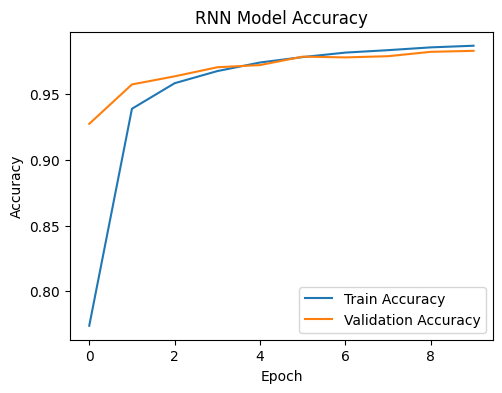

In [54]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

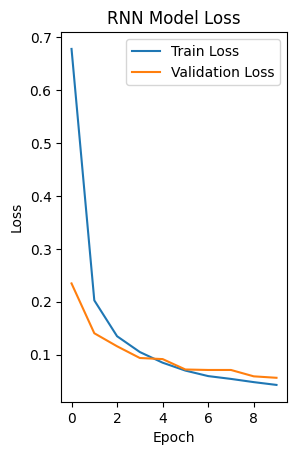

In [55]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()